## Importação de Bibliotecas

In [1]:
import pandas as pd
import re
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Criação de tabelas

In [11]:

PASTA_RASPAGEM = Path('../Raspagem')
PADRAO_ARQUIVO = re.compile(r'dados_aedes_(\d{8})_weekid(\d+)_(\d+)mosquitos')

COLS_MOSQUITO = [
    'aedes_aegypti_femea', 'aedes_aegypti_macho',
    'aedes_albopictus_femea', 'aedes_albopictus_macho',
    'culex_sp_femea', 'culex_sp_macho', 'total_mosquitos'
]

# Mapear arquivos e selecionar o mais atualizado por semana
arquivos = [
    {'arquivo': f, 'data_str': m.group(1), 'week_id': int(m.group(2)), 'n_mosquitos': int(m.group(3))}
    for f in PASTA_RASPAGEM.glob('*.xlsx')
    if (m := PADRAO_ARQUIVO.search(f.name))
]
df_meta = pd.DataFrame(arquivos)
selecionados = df_meta.loc[df_meta.groupby('week_id')['n_mosquitos'].idxmax()]

# Ler e concatenar arquivos selecionados
frames = []
for _, row in selecionados.iterrows():
    df = pd.read_excel(row['arquivo'])
    df['week_id']       = row['week_id']
    df['data_raspagem'] = pd.to_datetime(row['data_str'], format='%Y%m%d')
    frames.append(df)

# Agregar por week_id
df_all = pd.concat(frames, ignore_index=True)
df_all['mes'] = df_all['data_raspagem'].dt.month
df_all['ano'] = df_all['data_raspagem'].dt.year

df_final = (
    df_all
    .groupby(['week_id', 'data_raspagem', 'mes', 'ano'], as_index=False)[COLS_MOSQUITO]
    .sum()
    .sort_values('week_id')
    .reset_index(drop=True)
)


In [13]:
df_final.head()

,week_id,data_raspagem,mes,ano,aedes_aegypti_femea,aedes_aegypti_macho,aedes_albopictus_femea,aedes_albopictus_macho,culex_sp_femea,culex_sp_macho,total_mosquitos
0,450,2025-08-16,8,2025,2,0,0,0,50,10,62
1,451,2025-08-22,8,2025,1,0,0,0,39,2,42
2,452,2025-08-27,8,2025,1,0,0,6,78,7,92
3,453,2025-09-03,9,2025,4,0,0,0,34,7,45
4,454,2025-09-13,9,2025,9,0,0,0,55,10,74


## Distribuição dos Mosquitos ao Longo do Tempo

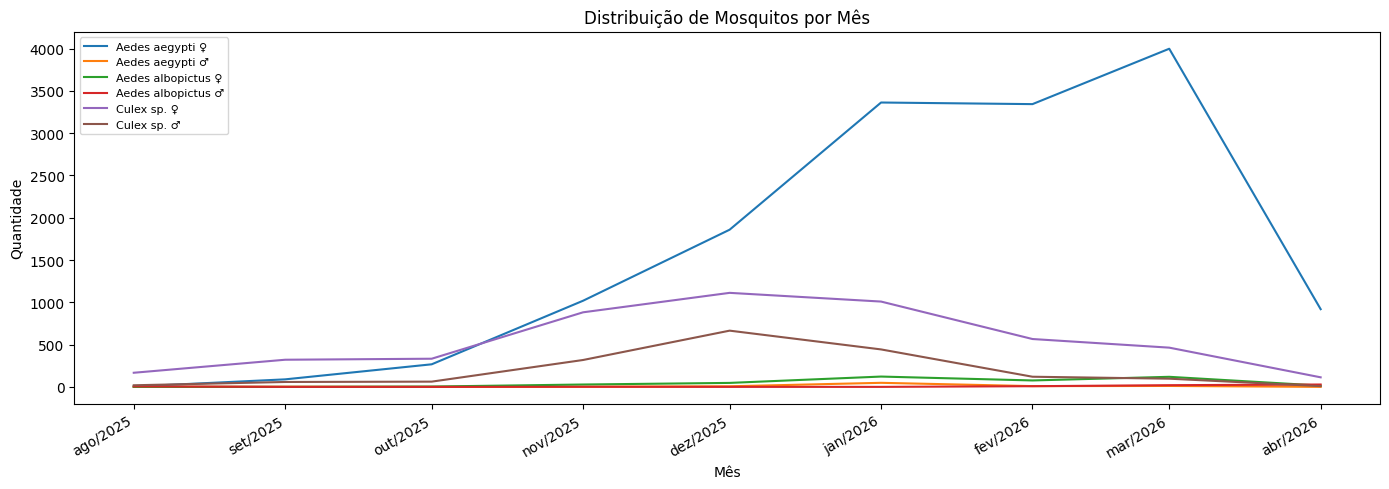

In [61]:

# Agrega por mês
df_final_mensal = df_final.copy()
df_final_mensal['data'] = df_final_mensal['data_raspagem'].dt.to_period('M').dt.to_timestamp()
df_final_mensal = df_final_mensal.groupby('data', as_index=False)[list(especies.keys()) if False else [
    'aedes_aegypti_femea', 'aedes_aegypti_macho',
    'aedes_albopictus_femea', 'aedes_albopictus_macho',
    'culex_sp_femea', 'culex_sp_macho',
]].sum()

fig, ax = plt.subplots(figsize=(14, 5))

especies = {
    'Aedes aegypti ♀':    'aedes_aegypti_femea',
    'Aedes aegypti ♂':    'aedes_aegypti_macho',
    'Aedes albopictus ♀': 'aedes_albopictus_femea',
    'Aedes albopictus ♂': 'aedes_albopictus_macho',
    'Culex sp. ♀':        'culex_sp_femea',
    'Culex sp. ♂':        'culex_sp_macho',
}

for label, col in especies.items():
    ax.plot(df_final_mensal['data'], df_final_mensal[col], label=label)

ax.set_title('Distribuição de Mosquitos por Mês')
ax.set_xlabel('Mês')
ax.set_ylabel('Quantidade')
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Distribuição dos Mosquitos ao Longo do Tempo (dados_marilia)

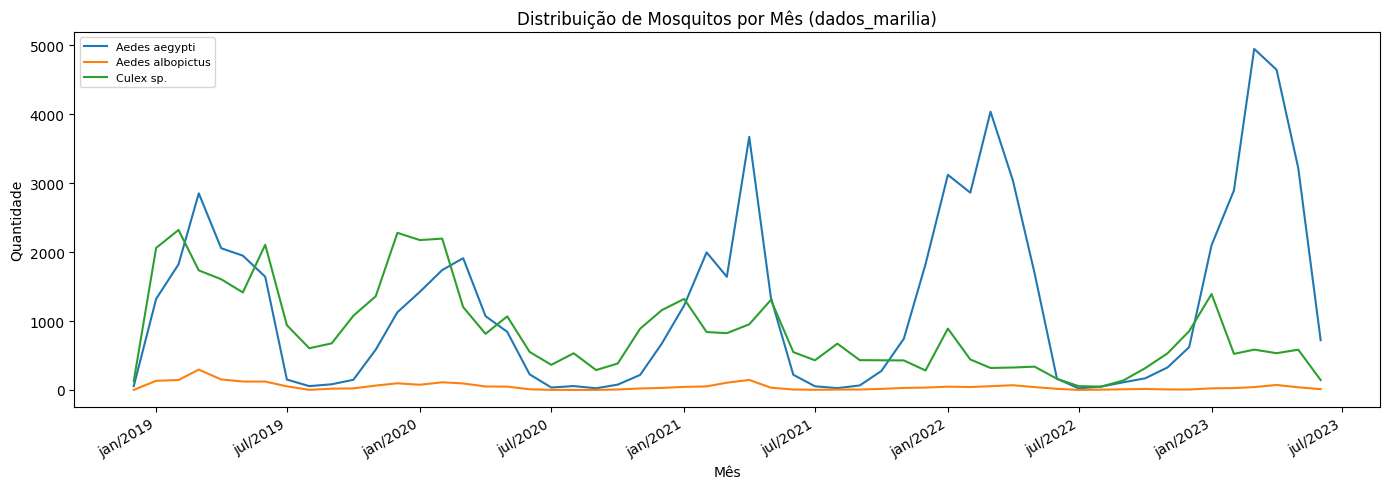

In [56]:

df_marilia = pd.read_csv('../dados_marilia/resumo_analise.csv')
df_marilia['Data Inicio'] = pd.to_datetime(df_marilia['Data Inicio'])

# Agrega por mês
df_marilia_mensal = df_marilia.copy()
df_marilia_mensal['data'] = df_marilia_mensal['Data Inicio'].dt.to_period('M').dt.to_timestamp()
df_marilia_mensal = df_marilia_mensal.groupby('data', as_index=False)[['Aedes aegypti', 'Aedes albopictus', 'Culex sp']].sum()

fig, ax = plt.subplots(figsize=(14, 5))

especies_marilia = {
    'Aedes aegypti':    'Aedes aegypti',
    'Aedes albopictus': 'Aedes albopictus',
    'Culex sp.':        'Culex sp',
}

for label, col in especies_marilia.items():
    ax.plot(df_marilia_mensal['data'], df_marilia_mensal[col], label=label)

ax.set_title('Distribuição de Mosquitos por Mês (dados_marilia)')
ax.set_xlabel('Mês')
ax.set_ylabel('Quantidade')
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [24]:

MESES = ['janeiro','fevereiro','março','abril','maio','junho',
         'julho','agosto','setembro','outubro','novembro','dezembro']

def fmt_ptbr(d):
    return f"{d.day} de {MESES[d.month - 1]} de {d.year}"

inicio = df_marilia['Data Inicio'].min()
fim    = df_marilia['Data Inicio'].max()
print(f"{fmt_ptbr(inicio)}\naté\n{fmt_ptbr(fim)}")


30 de dezembro de 2018
até
4 de junho de 2023


## Casos de Dengue por Mês — Porto Alegre (2020–2025)


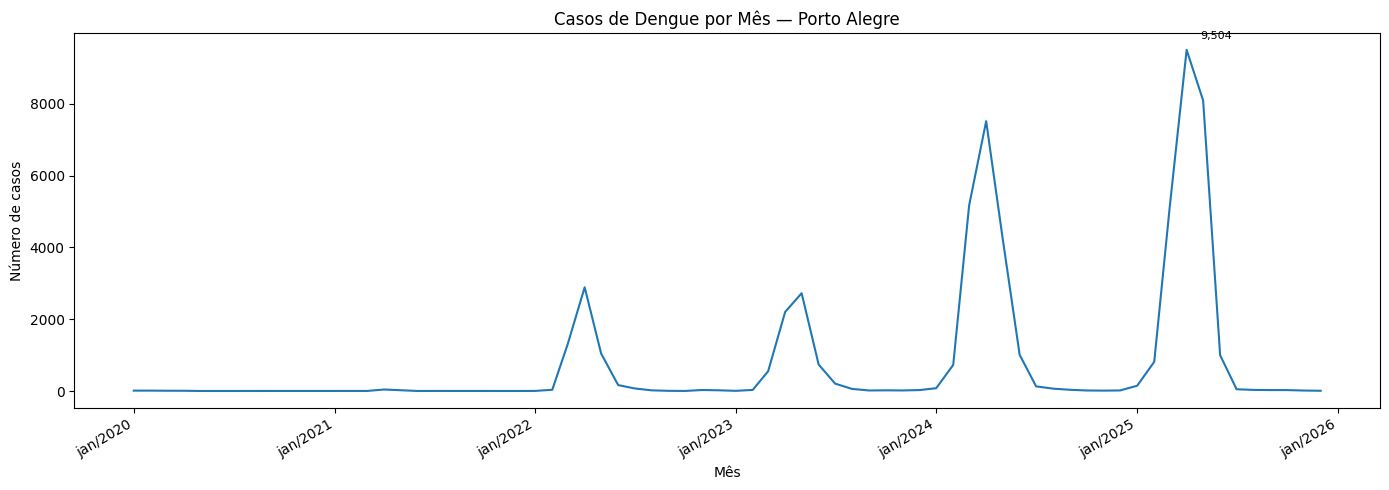

In [27]:
df_dengue = pd.read_csv('../Bases de dados/base_oficial_filtrada_poa/dengue_poa_mensal.csv')
df_dengue['data'] = pd.to_datetime(df_dengue.rename(columns={'ano': 'year', 'mes': 'month'})[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_dengue['data'], df_dengue['casos'])

# Anotação do pico
idx_pico = df_dengue['casos'].idxmax()
pico = df_dengue.loc[idx_pico]
ax.annotate(
    f"{int(pico['casos']):,}",
    xy=(pico['data'], pico['casos']),
    xytext=(10, 8), textcoords='offset points',
    fontsize=8
)

ax.set_title('Casos de Dengue por Mês — Porto Alegre')
ax.set_xlabel('Mês')
ax.set_ylabel('Número de casos')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Distribuicao de casos ao longo de 2025

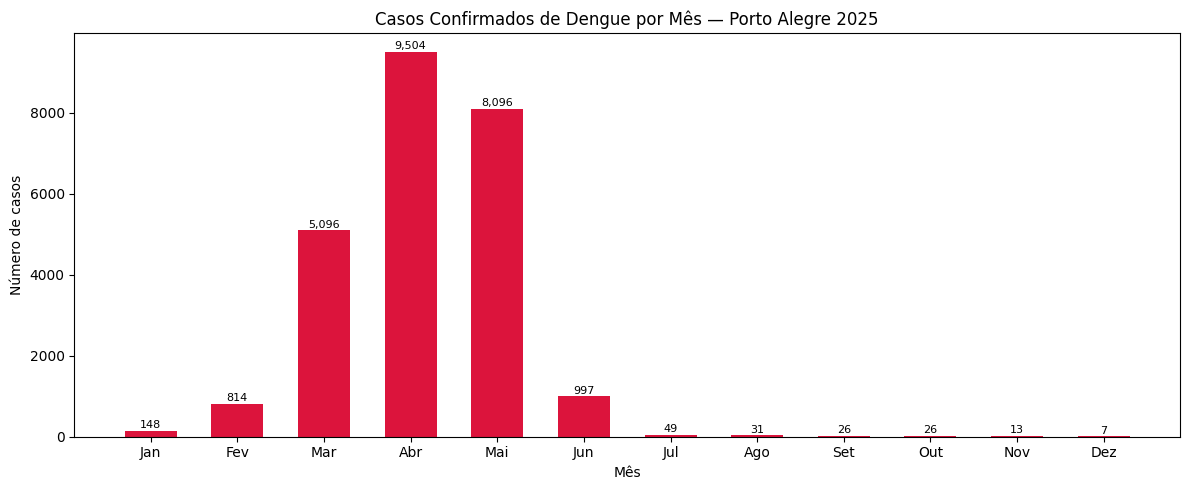

In [32]:
dengue_2025 = df_dengue[df_dengue['data'].dt.year == 2025].copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(dengue_2025['data'].dt.month, dengue_2025['casos'], color='crimson', width=0.6)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MESES_PT)
ax.set_title('Casos Confirmados de Dengue por Mês — Porto Alegre 2025')
ax.set_xlabel('Mês')
ax.set_ylabel('Número de casos')

for _, row in dengue_2025.iterrows():
    if row['casos'] > 0:
        ax.text(row['data'].month, row['casos'] + 20, f"{int(row['casos']):,}",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


## Preparação das tabelas pré-merge


In [46]:

# marilia_pre_merge: data semanal da Marília, apenas Aedes aegypti
marilia_pre_merge = (
    df_marilia[['Data Inicio', 'Aedes aegypti']]
    .rename(columns={'Data Inicio': 'data', 'Aedes aegypti': 'mosquitos_capturados'})
    .assign(
        mes=lambda d: d['data'].dt.month,
        ano=lambda d: d['data'].dt.year,
    )
    [['data', 'mes', 'ano', 'mosquitos_capturados']]
    .sort_values('data')
    .reset_index(drop=True)
)

marilia_pre_merge


,data,mes,ano,mosquitos_capturados
0,2018-12-30,12,2018,55
1,2019-01-06,1,2019,57
2,2019-01-13,1,2019,455
3,2019-01-20,1,2019,371
4,2019-01-27,1,2019,438
...,...,...,...,...
227,2023-05-07,5,2023,594
228,2023-05-14,5,2023,592
229,2023-05-21,5,2023,993
230,2023-05-28,5,2023,1040


In [47]:

# raspagem_pre_merge: data semanal da raspagem, apenas Aedes aegypti fêmea
raspagem_pre_merge = (
    df_final[['data_raspagem', 'aedes_aegypti_femea']]
    .rename(columns={'data_raspagem': 'data', 'aedes_aegypti_femea': 'mosquitos_capturados'})
    .assign(
        mes=lambda d: d['data'].dt.month,
        ano=lambda d: d['data'].dt.year,
    )
    [['data', 'mes', 'ano', 'mosquitos_capturados']]
    .sort_values('data')
    .reset_index(drop=True)
)

raspagem_pre_merge


,data,mes,ano,mosquitos_capturados
0,2025-08-16,8,2025,2
1,2025-08-22,8,2025,1
2,2025-08-27,8,2025,1
3,2025-09-03,9,2025,4
4,2025-09-13,9,2025,9
5,2025-09-20,9,2025,27
6,2025-09-27,9,2025,49
7,2025-10-04,10,2025,62
8,2025-10-16,10,2025,113
9,2025-10-22,10,2025,92


In [52]:

# Ver as linhas de raspagem_pre_merge a partir de ago/2025
print(raspagem_pre_merge[raspagem_pre_merge['ano'] >= 2025].to_string())


         data  mes   ano  mosquitos_capturados
0  2025-08-16    8  2025                     2
1  2025-08-22    8  2025                     1
2  2025-08-27    8  2025                     1
3  2025-09-03    9  2025                     4
4  2025-09-13    9  2025                     9
5  2025-09-20    9  2025                    27
6  2025-09-27    9  2025                    49
7  2025-10-04   10  2025                    62
8  2025-10-16   10  2025                   113
9  2025-10-22   10  2025                    92
10 2025-11-01   11  2025                   208
11 2025-11-07   11  2025                   182
12 2025-11-14   11  2025                   173
13 2025-11-22   11  2025                   203
14 2025-11-29   11  2025                   253
15 2025-12-06   12  2025                   473
16 2025-12-13   12  2025                   495
17 2025-12-20   12  2025                   343
18 2025-12-24   12  2025                   246
19 2025-12-31   12  2025                   302
20 2026-01-10

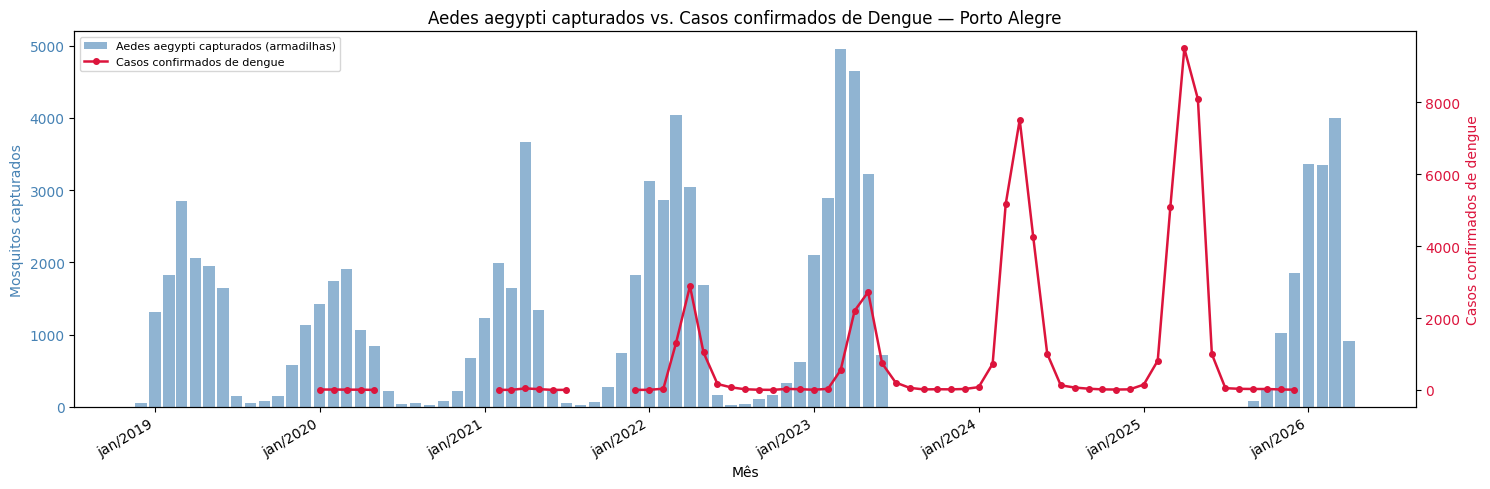

In [58]:

# Cria coluna de data para o eixo X
df_plot2 = df_base_final.copy()
df_plot2['data'] = pd.to_datetime(df_plot2[['ano', 'mes']].rename(columns={'ano': 'year', 'mes': 'month'}).assign(day=1))

fig, ax1 = plt.subplots(figsize=(15, 5))

# Eixo esquerdo — mosquitos capturados
color_arm = 'steelblue'
ax1.bar(df_plot2['data'], df_plot2['mosquitos_capturados'], width=25,
        color=color_arm, alpha=0.6, label='Aedes aegypti capturados (armadilhas)')
ax1.set_ylabel('Mosquitos capturados', color=color_arm)
ax1.tick_params(axis='y', labelcolor=color_arm)

# Eixo direito — casos reais
ax2 = ax1.twinx()
color_den = 'crimson'
ax2.plot(df_plot2['data'], df_plot2['casos_reais'], color=color_den,
         linewidth=1.8, marker='o', markersize=4, label='Casos confirmados de dengue')
ax2.set_ylabel('Casos confirmados de dengue', color=color_den)
ax2.tick_params(axis='y', labelcolor=color_den)

# Legenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

ax1.set_title('Aedes aegypti capturados vs. Casos confirmados de Dengue — Porto Alegre')
ax1.set_xlabel('Mês')
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
